# Modelagem e exploração dos dados em um experimento de detecção de vazamentos

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais | 15615790 |
| Guilherme de Abreu Barreto | 12543033 |

## Introdução

Nesta análise, pretende-se a modelagem e exploração inicial dos dados de um problema de classificação, descrito no artigo de Zanfei et al., [_Novel approach for burst detection in water distribution systems based on graph neural networks_](https://www.sciencedirect.com/science/article/abs/pii/S2210670722004073). Neste, os autores propõem o uso de técnicas de Apredizado de Máquina (_Machine Learning, ML_) para a detecção da ocorrência de vazamentos em uma rede de distribuição de água (_Water Distribution System, WDS_).

Em nosso experimento, integramos os [dados sintéticos](https://github.com/ArieleZanfei/generated-datasets-for-burst-detection-in-water-distribution-systems?tab=readme-ov-file) de pressão e vazão gerados pelos autores com os dados do modelo [Modena](https://uknowledge.uky.edu/wdst_international/5/) de WDS descrito em formato de arquivo `.inp` do software EPANET. Para tal fazemos uso da ferramenta SQLite para a criação e população de um banco de dados local e de pequeno porte. Em seguida passamos a requisitar os dados armazenados neste para extração de métricas para uma descrição exploratória do sistema.

São descritos os pontos em que encontramos dificuldades metodológicas para a reprodução de resultados vistos no artigo.

## Dependências

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from epyt import epanet
from functools import partial
from dataclasses import dataclass, fields
from datetime import datetime
from sqlalchemy import (
    CheckConstraint as constraint,
    Enum,
    ForeignKey as fk,
    ForeignKeyConstraint as fkc,
    PrimaryKeyConstraint as pkc,
    String,
    select,
    create_engine,
    func,
    case,
)
from sqlalchemy.orm import (
    aliased,
    composite,
    declared_attr,
    declarative_base,
    Mapped,
    relationship,
    sessionmaker,
    mapped_column as column,
    validates,
)
from pathlib import Path
from sqlalchemy.ext.hybrid import hybrid_property
from tqdm import tqdm
from typing import Any, Optional, final

## Carregamento do modelo de WDS para EPANET

Com o uso da biblioteca EPyT carregamos um objeto `wds` pelo qual realizamos acesso aos dados referentes a descrição do modelo Modena. A seguir exibimos o modelo com destaque para os nós aqueles que os autores destacaram como tendo sido selecionados para observação em sua análise.

EPANET version 20200 loaded (EPyT version v1.2.2 - Last Update: 10/05/2025).
Input File modena.inp loaded successfully.



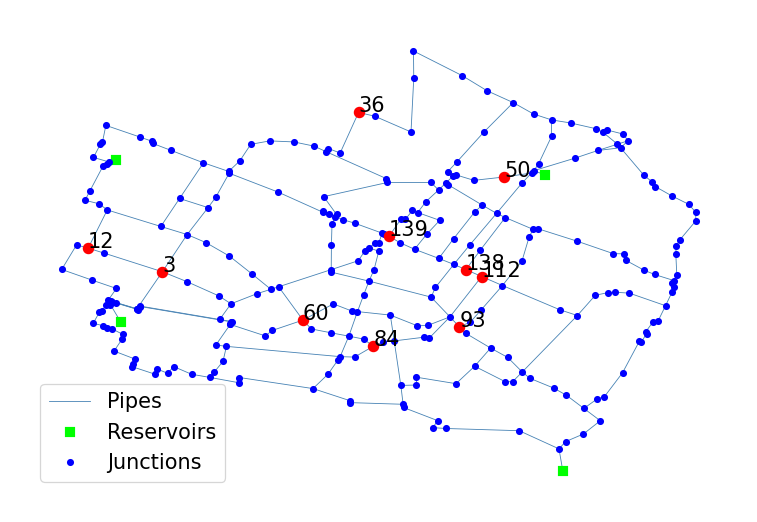

In [2]:
wds = epanet('modena.inp')

# A list of the nodes where the sensors are located.
sensors = ['3', '12', '36', '50', '60', '84', '93', '112', '138', '139']
fig = wds.plot(nodesID=sensors, highlightnode=sensors)

Pela imagem, vemos que estes nós não correspondem aqueles que figuram no mapa que os autores exibiram em seu artigo, exibido abaixo (o mapa encontra-se rotacionado no artigo original).

![Representação dos autores no artigo](imgs/modena_artigo.png)

## Modelagem do Banco de Dados

Abaixo descrevemos as tabelas a compor o _schema_ nosso banco de dados. Como resultado da inserção destas, tem-se um banco de dados conforme o seguinte diagrama:

![Diagrama do banco de dados](imgs/diagrama_bd.png)

### Função auxiliar

Um _syntax sugar_ para descrever relações entre tabelas pai e filhas onde a chave principal da tabela filha é herdada da tabela pai

In [7]:
def parentPrimaryKey(parent: str) -> Mapped[Any]:
    return column(fk(f"{parent}.id", ondelete="CASCADE"), primary_key=True)

### Tabela `Pipe`

Descreve os canos, as arestas vistas no diagrama acima.

In [ ]:
Base = declarative_base()


@final
class Pipe(Base):
    __tablename__ = "pipes"

    # Attributes
    id: Mapped[int] = column(primary_key=True, autoincrement=True)
    length: Mapped[float]
    diameter: Mapped[float]
    roughness: Mapped[float] = column(default=130.0)
    minor_loss: Mapped[float] = column(default=0.0)
    is_open: Mapped[bool] = column(default=True)

    # Foreign keys
    upstream_node_id: Mapped[int] = column(
        fk("nodes.id", ondelete="CASCADE")
    )
    downstream_node_id: Mapped[int] = column(
        fk("nodes.id", ondelete="CASCADE")
    )

    # Relationships
    upstream_node: Mapped["Node"] = relationship(
        foreign_keys=[upstream_node_id],
        backref="downstream_pipes"
    )
    downstream_node: Mapped["Node"] = relationship(
        foreign_keys=[downstream_node_id],
        backref="upstream_pipes"
    )

    __table_args__ = (
        constraint(
            "upstream_node_id != downstream_node_id",
            name="ck_undirected_pipe_constraint"),
    )

### Tabela `Node`

Descrevem os nós no diagrama. Os nós podem descrever uma variedade de objetos no esquema de modelagem no EPANET, mas em nosso problema eles podem descrever apenas a dois objetos: junções e reservatórios. Estes são detalhados em suas respectivas tabelas à seguir.

In [ ]:
@final
class Node(Base):
    __tablename__: str = "nodes"

    # Attributes
    @dataclass
    class Coordinates:
        x: float
        y: float

    id: Mapped[int] = column(primary_key=True, autoincrement=True)
    coordinates: Mapped[Coordinates] = composite(
        *[column(f.name) for f in fields(Coordinates)]
    )

    # Relationships
    junction: Mapped[Optional["Junction"]] = relationship(backref="node")
    reservoir: Mapped[Optional["Reservoir"]] = relationship(backref="node")

    # Computed properties for connected nodes
    @property
    def downstream_nodes(self) -> list["Node"]:
        """Nodes that are downstream of this node"""
        return [pipe.downstream_node for pipe in self.downstream_pipes]
    
    @property
    def upstream_nodes(self) -> list["Node"]:
        """Nodes that are upstream of this node"""
        return [pipe.upstream_node for pipe in self.upstream_pipes]
    
    @property
    def all_connected_nodes(self) -> list["Node"]:
        """All nodes connected to this node through pipes"""
        return self.downstream_nodes + self.upstream_nodes


@final
class Junction(Base):
    __tablename__ = "junctions"

    # Attributes
    id: Mapped[int] = parentPrimaryKey("nodes")
    elevation: Mapped[float]
    demand: Mapped[float]

    # Relationships
    pressure_readings: Mapped[list["Pressure"]] = relationship(backref="junction")



@final
class Reservoir(Base):
    __tablename__ = "reservoirs"

    # Attributes
    id: Mapped[int] = parentPrimaryKey("nodes")
    head: Mapped[float]

    # Relationships
    flow_readings: Mapped[list["Flow"]] = relationship(backref="reservoir")

### Tabelas `Observation`, `Pressure` e `Flow`

Respectivamente descrevem:

- O cenário da simulação, os instantes de tempo em que é tida uma observação, e se em cada instante há vazamento no sistema;
- A pressão atestada nos vários nós, para cada cenário e instante de tempo.
- A vazão atestada nos reservatórios, para cada cenário e instante de tempo.

In [8]:
class Reading(Base):
    __abstract__: bool = True

    # Attributes
    reading: Mapped[float]

    # Foreign keys
    scenario: Mapped[int]
    observation_id: Mapped[int]

    @declared_attr
    def observation(cls)-> Mapped["Observation"]:
        return relationship(backref=cls.__tablename__)

    @classmethod
    def get_base_table_args(cls) -> tuple[fkc, ]:
        return (
            fkc(
                ["observation_id", "scenario"],
                ["observations.id", "observations.scenario"],
                ondelete="CASCADE"
            ),
        )


@final
class Pressure(Reading):
    __tablename__ = "pressure_readings"

    # Foreign keys
    junction_id: Mapped[int] = column(
        fk("junctions.id", ondelete="CASCADE")
    )

    @declared_attr
    def __table_args__(cls):
        return (
            pkc("scenario", "observation_id", "junction_id"),
        ) + super().get_base_table_args()


@final
class Flow(Reading):
    __tablename__ = "flow_readings"

    # Foreign keys
    reservoir_id: Mapped[int] = column(
        fk("reservoirs.id", ondelete="CASCADE")
    )

    @declared_attr
    def __table_args__(cls):
        return (
            pkc("scenario", "observation_id", "reservoir_id"),
        ) + super().get_base_table_args()
    


@final
class Observation(Base):
    __tablename__ = "observations"

    # Attributes
    id: Mapped[int]
    scenario: Mapped[int]
    timestamp: Mapped[datetime]
    burst: Mapped[bool]

    __table_args__ = (pkc("id", "scenario"),)

## Inserção do `schema` no banco de dados

In [4]:
engine = create_engine(f"sqlite:///modena.db", echo=True)
Session = sessionmaker(bind=engine)

In [5]:
Base.metadata.create_all(engine)

2025-09-28 16:42:02,441 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 16:42:02,442 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("pipes")
2025-09-28 16:42:02,442 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-28 16:42:02,444 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("pipes")
2025-09-28 16:42:02,444 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-28 16:42:02,445 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("nodes")
2025-09-28 16:42:02,446 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-28 16:42:02,448 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("nodes")
2025-09-28 16:42:02,449 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-28 16:42:02,450 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("junctions")
2025-09-28 16:42:02,451 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-09-28 16:42:02,452 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("junctions")
2025-09-28 16:42:02,452 INFO sqlalchemy.engine.Engine [raw sql] ()
202

## População do banco de dados

### Inserção dos nós

In [7]:
with Session() as session:
    coords = wds.getNodeCoordinates()
    nodes = [
        Node(x=x, y=y)
        for x, y in zip(coords['x'].values(), coords['y'].values())
    ]
    session.add_all(nodes)
    session.commit()

2025-09-28 16:42:02,595 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 16:42:02,602 INFO sqlalchemy.engine.Engine INSERT INTO nodes (x, y) VALUES (?, ?) RETURNING id
2025-09-28 16:42:02,603 INFO sqlalchemy.engine.Engine [generated in 0.00081s (insertmanyvalues) 1/272 (ordered; batch not supported)] (1650094.63, 4944639.0)
2025-09-28 16:42:02,605 INFO sqlalchemy.engine.Engine INSERT INTO nodes (x, y) VALUES (?, ?) RETURNING id
2025-09-28 16:42:02,605 INFO sqlalchemy.engine.Engine [insertmanyvalues 2/272 (ordered; batch not supported)] (1650348.88, 4944585.0)
2025-09-28 16:42:02,607 INFO sqlalchemy.engine.Engine INSERT INTO nodes (x, y) VALUES (?, ?) RETURNING id
2025-09-28 16:42:02,607 INFO sqlalchemy.engine.Engine [insertmanyvalues 3/272 (ordered; batch not supported)] (1650592.63, 4945068.0)
2025-09-28 16:42:02,608 INFO sqlalchemy.engine.Engine INSERT INTO nodes (x, y) VALUES (?, ?) RETURNING id
2025-09-28 16:42:02,609 INFO sqlalchemy.engine.Engine [insertmanyvalues 4/272 (

### Inserção das junções

In [8]:
with Session() as session:
    elevations = wds.getNodeElevations()
    demands = wds.getNodeBaseDemands()[1]
    junctions = [
        Junction(id = i, elevation=elevations[i - 1], demand=demands[i - 1])
        for i in wds.getNodeJunctionIndex()
    ]
    session.add_all(junctions)
    session.commit()

2025-09-28 16:42:03,272 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 16:42:03,277 INFO sqlalchemy.engine.Engine INSERT INTO junctions (id, elevation, demand) VALUES (?, ?, ?)
2025-09-28 16:42:03,277 INFO sqlalchemy.engine.Engine [generated in 0.00135s] [(1, 39.4900016784668, 0.05999999865889549), (2, 39.619998931884766, 1.4500000476837158), (3, 38.70000076293945, 5.130000114440918), (4, 37.25, 2.759999990463257), (5, 36.27000045776367, 0.9599999785423279), (6, 35.95000076293945, 0.7799999713897705), (7, 35.95000076293945, 1.0299999713897705), (8, 36.09000015258789, 2.119999885559082)  ... displaying 10 of 268 total bound parameter sets ...  (267, 36.209999084472656, 1.690000057220459), (268, 35.61000061035156, 0.4300000071525574)]
2025-09-28 16:42:03,283 INFO sqlalchemy.engine.Engine COMMIT


### Inserção dos reservatórios

In [9]:
with Session() as session:
    heads = wds.getNodeElevations()
    reservoirs = [
        Reservoir(id = i, head = heads[i - 1])
        for i in wds.getNodeReservoirIndex()
    ]
    session.add_all(reservoirs)
    session.commit()

2025-09-28 16:42:03,302 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 16:42:03,305 INFO sqlalchemy.engine.Engine INSERT INTO reservoirs (id, head) VALUES (?, ?)
2025-09-28 16:42:03,306 INFO sqlalchemy.engine.Engine [generated in 0.00107s] [(269, 72.0), (270, 73.80000305175781), (271, 73.0), (272, 74.5)]
2025-09-28 16:42:03,308 INFO sqlalchemy.engine.Engine COMMIT


### Inserção dos canos

In [ ]:
with Session() as session:
    with open('modena.inp', 'r') as file:
        pipes = []
        index = 0
        lines = file.readlines()
        for line in lines:
            if line.strip() == "[PIPES]":
                break
            index += 1
        index += 2
 
        for line in lines[index:]:
            if line.strip() == "":
                break
            parameters = line.split()
            pipes.append(
                Pipe(
                    id=int(parameters[0]),
                    upstream_node_id=int(parameters[1]),
                    downstream_node_id=int(parameters[2]),
                    length=float(parameters[3]),
                    diameter=float(parameters[4]),
                    roughness=float(parameters[5]),
                    minor_loss=float(parameters[6]),
                    is_open=True if parameters[7] == 'Open' else False
                )
            )
        session.add_all(pipes)
        session.commit()

### Inserção das leituras

Em seguida avaliamos os documentos `WDts1_dataset.csv` e `WDts1_pressures.csv`. No primeiro constam as seguintes informações:

- Momento da medição;
- Vazão em cada um dos reservatórios;
- Pressão em nós indicados pelos autores.

No segundo consta:

- Momento da medição;
- Pressão em cada um dos nós da rede.

Buscamos consolidar estas informações, mas ao compararmos as medidas de pressão em cada um desses documentos, constatamos que estas não são as mesmas para os nós que o autor selecionou em ambos os documentos.

In [11]:
repo_url = "https://github.com/ArieleZanfei/generated-datasets-for-burst-detection-in-water-distribution-systems.git"
repo_name = repo_url.split('/')[-1].replace('.git', '')

# Load both CSV files
df1 = pd.read_csv(f"{repo_name}/WDts1/WDts1_pressures.csv")  # Has columns: 1, 2, 3, 4, ...
df2 = pd.read_csv(f"{repo_name}/WDts1/WDts1_dataset.csv", sep=';')  # Has columns: 3_press, 12_press  ...

# Create a mapping between column names
column_mapping = {i : f"{i}_press" for i in sensors}

print("Comparing values:")
for col1, col2 in column_mapping.items():
    if col1 in df1.columns and col2 in df2.columns:
        # Compare the columns
        values_match = df1[col1].equals(df2[col2])
        print(f"Column {col1} vs {col2}: {values_match}")
        
        # If you want to see specific differences
        if not values_match:
            differences = df1[col1] != df2[col2]
            print(f"  Number of differing values: {differences.sum()}")
    else:
        print(f"Missing columns: {col1} in df1: {col1 in df1.columns}, {col2} in df2: {col2 in df2.columns}")

Comparing values:
Column 3 vs 3_press: False
  Number of differing values: 35040
Column 12 vs 12_press: False
  Number of differing values: 35040
Column 36 vs 36_press: False
  Number of differing values: 35039
Column 50 vs 50_press: False
  Number of differing values: 35040
Column 60 vs 60_press: False
  Number of differing values: 35040
Column 84 vs 84_press: False
  Number of differing values: 35040
Column 93 vs 93_press: False
  Number of differing values: 35040
Column 112 vs 112_press: False
  Number of differing values: 35025
Column 138 vs 138_press: False
  Number of differing values: 35023
Column 139 vs 139_press: False
  Number of differing values: 35040


Isso nos obriga a, para a reprodutibilidade das condições em que o autor fez seu experimento, atemo-nos apenas aos dados que o mesmo selecionou. Ests são adicionados ao banco de dados a seguir.

In [12]:
repo_url = "https://github.com/ArieleZanfei/generated-datasets-for-burst-detection-in-water-distribution-systems.git"
repo_folder = "../" + repo_url.split('/')[-1].replace('.git', '')

with Session() as session:
    for scenario in range(1, 5):
        observations = []
        flow_readings = []
        pressure_readings = []
        df = pd.read_csv(
            f"{repo_name}/WDts{scenario}/WDts{scenario}_dataset.csv", sep=';'
        )
        
        for index, row in df.iterrows():
            observation_id = index + 1
            observations.append(
                Observation(
                    id=observation_id,
                    scenario=scenario,
                    timestamp=pd.to_datetime(row['index'], format='%Y-%m-%d %H:%M:%S'),
                    burst=row['burst'],
                )
            )
            for i, idx in enumerate(wds.getNodeReservoirIndex(), start=1):
                flow_readings.append(
                    Flow(
                        reservoir_id=idx,
                        scenario=scenario,
                        observation_id=observation_id,
                        reading=row[f"flow_meter{i}"],
                    )
                )
            for idx in sensors:
                pressure_readings.append(
                    Pressure(
                        junction_id=idx,
                        scenario=scenario,
                        observation_id=observation_id,
                        reading=row[f"{idx}_press"],
                    )
                )
        session.add_all(observations)
        session.commit()
        session.add_all(flow_readings + pressure_readings)
        session.commit()

2025-09-28 16:42:59,664 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 16:43:00,440 INFO sqlalchemy.engine.Engine INSERT INTO observations (id, scenario, timestamp, burst) VALUES (?, ?, ?, ?)
2025-09-28 16:43:00,440 INFO sqlalchemy.engine.Engine [generated in 0.27549s] [(1, 1, '2010-01-01 00:00:00.000000', 0), (2, 1, '2010-01-01 01:00:00.000000', 0), (3, 1, '2010-01-01 02:00:00.000000', 0), (4, 1, '2010-01-01 03:00:00.000000', 0), (5, 1, '2010-01-01 04:00:00.000000', 0), (6, 1, '2010-01-01 05:00:00.000000', 0), (7, 1, '2010-01-01 06:00:00.000000', 0), (8, 1, '2010-01-01 07:00:00.000000', 0)  ... displaying 10 of 35040 total bound parameter sets ...  (35039, 1, '2013-12-30 22:00:00.000000', 0), (35040, 1, '2013-12-30 23:00:00.000000', 0)]
2025-09-28 16:43:01,077 INFO sqlalchemy.engine.Engine COMMIT
2025-09-28 16:43:15,444 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 16:43:17,673 INFO sqlalchemy.engine.Engine INSERT INTO flow_readings (reservoir_id, reading, scena

## Análises preliminares

A seguir realizamos algumas explorações iniciais dos conjuntos de dados. Iniciamos a valiar a disperção em que ocorrem momentos de falha em cada um dos cenários a serem avaliados. Atestamos a ausência de um padrão claro o qul se possa atestar visualmente apenas.

2025-09-28 18:39:40,586 INFO sqlalchemy.engine.Engine SELECT observations.id, observations.scenario, observations.burst 
FROM observations
2025-09-28 18:39:40,589 INFO sqlalchemy.engine.Engine [cached since 722.2s ago] ()


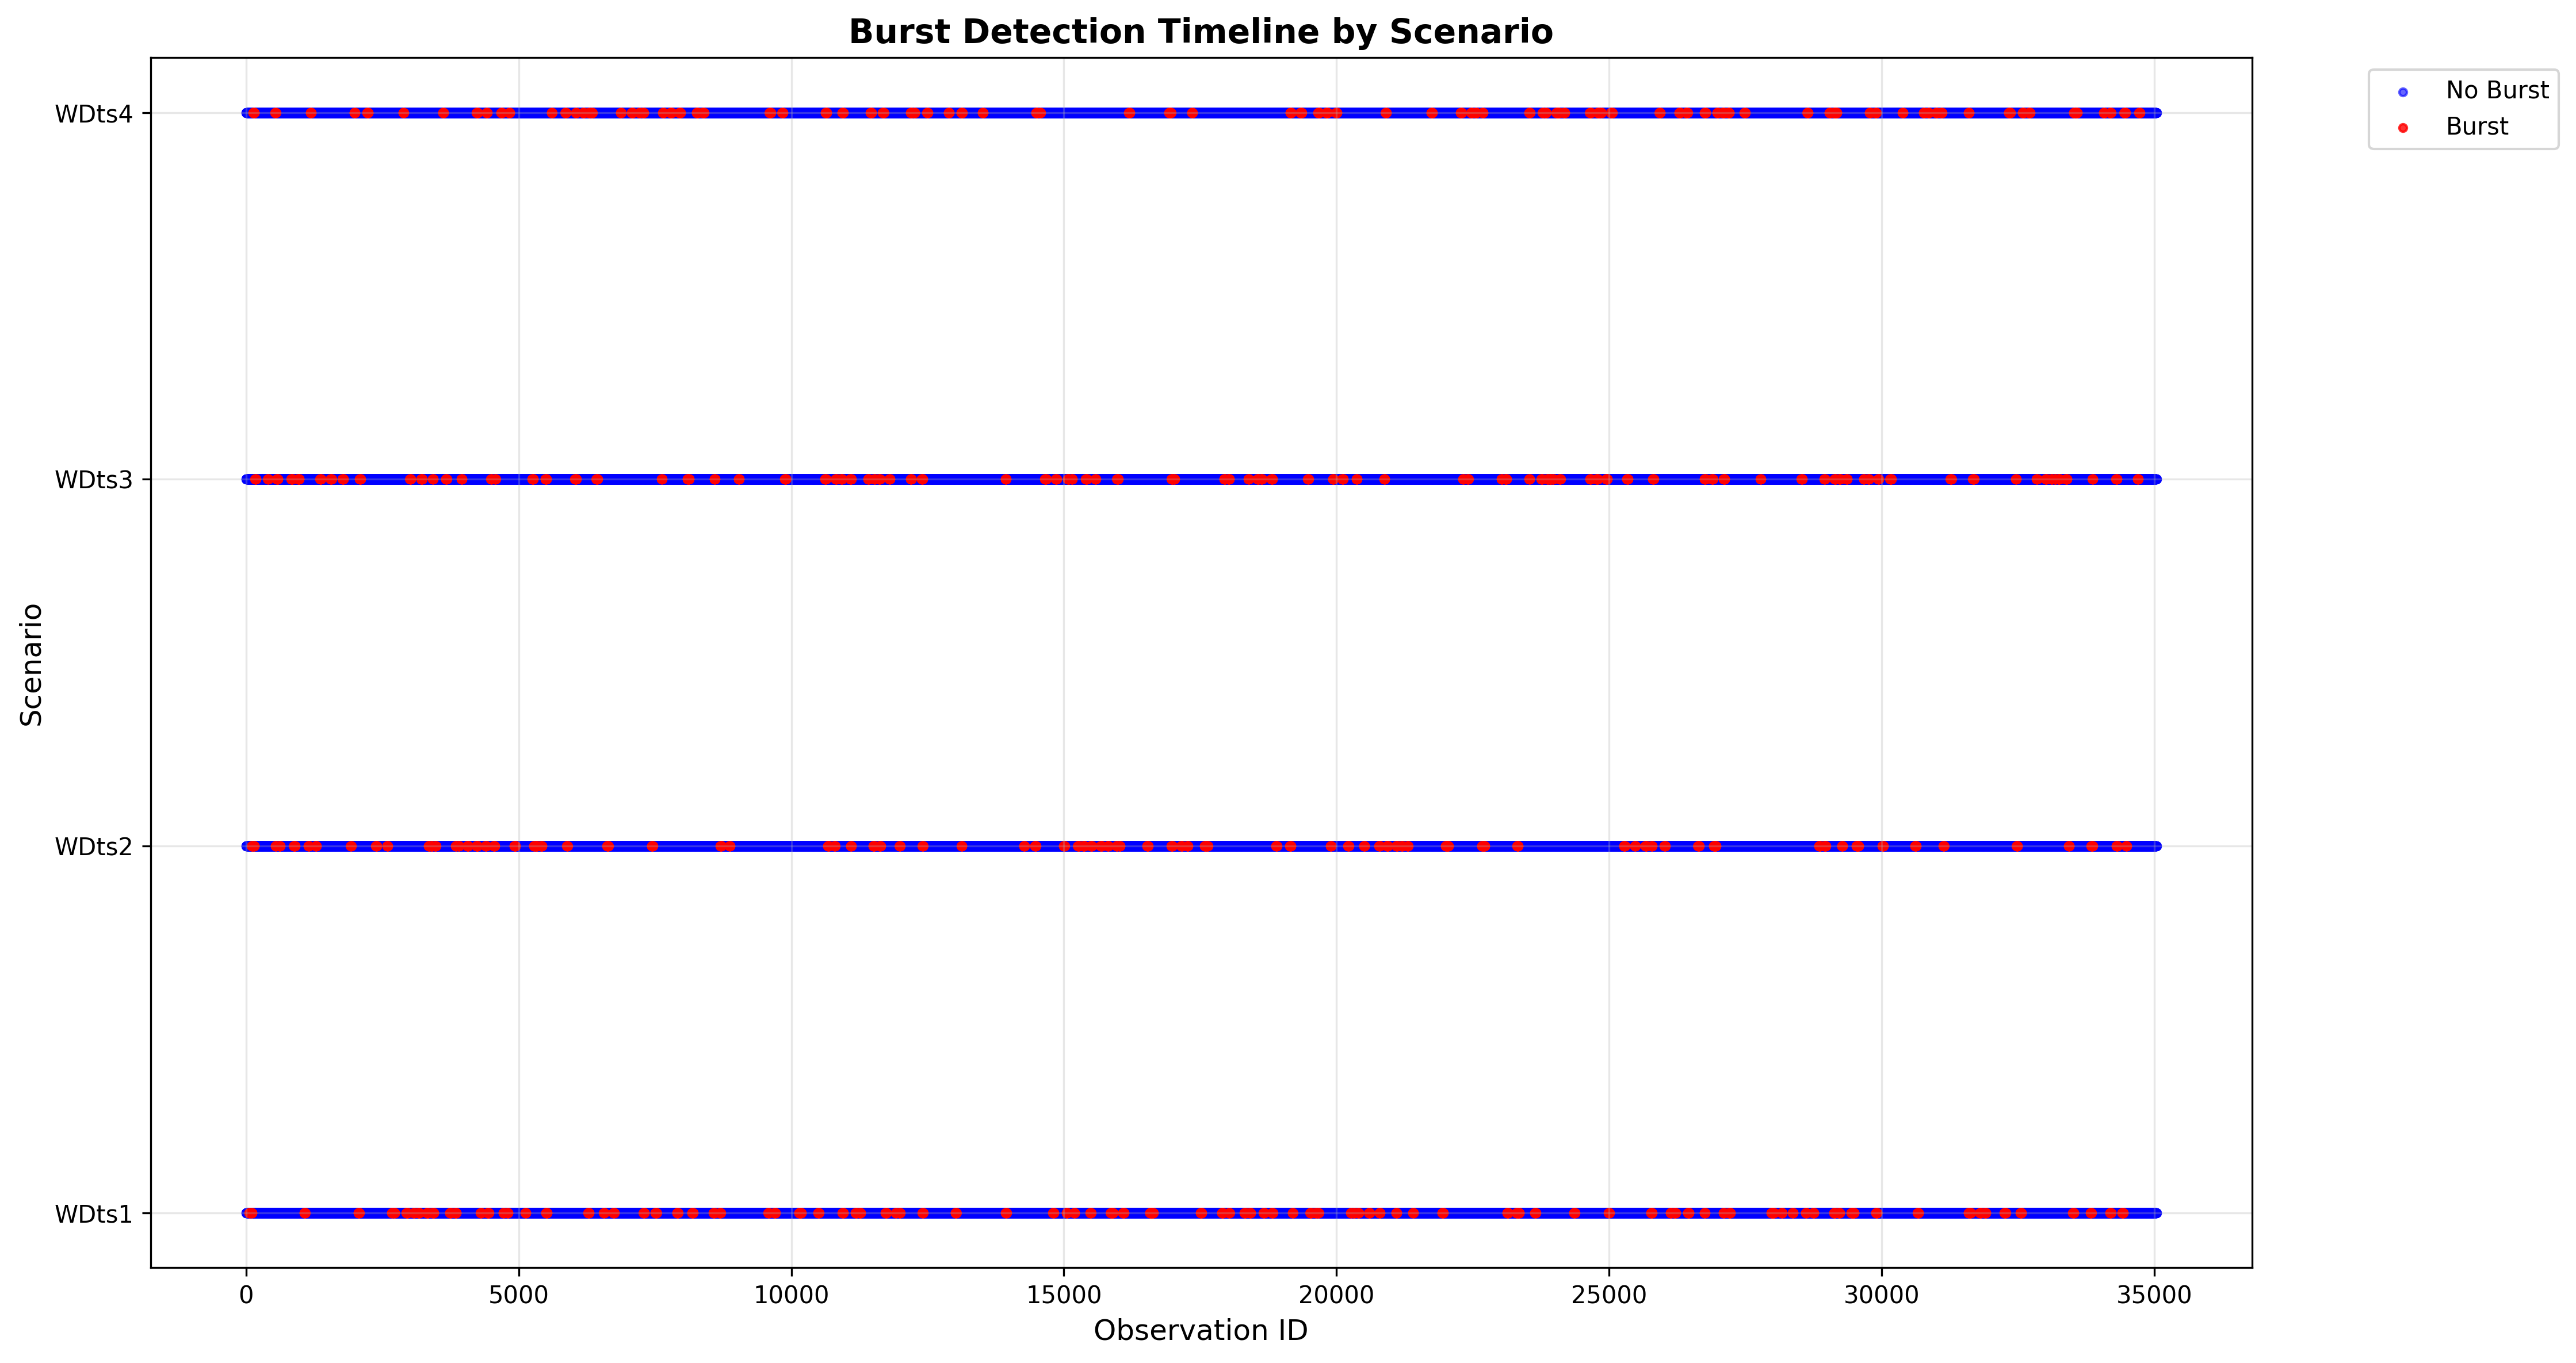

In [26]:
with Session() as session:
    # Fetch the required columns
    query = select(Observation.id, Observation.scenario, Observation.burst)
    result = session.execute(query)
    
    # Convert to DataFrame for manipulation
    df = pd.DataFrame(result.mappings().all())
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Define colors
    false_color = 'blue'
    true_color = 'red'
    
    # Create scatter plot for each scenario
    scenarios = sorted(df['scenario'].unique())
    
    for scenario in sorted(df['scenario'].unique()):
        # Filter data for this scenario
        scenario_data = df[df['scenario'] == scenario]
        
        # Separate burst True and False
        burst_false = scenario_data[scenario_data['burst'] == False]
        burst_true = scenario_data[scenario_data['burst'] == True]
        
        # Plot burst False (blue)
        plt.scatter(burst_false['id'], [scenario] * len(burst_false), 
                    color=false_color, label=f'No Burst' if scenario == scenarios[0] else "",
                    alpha=0.6, s=10)
        
        # Plot burst True (red)
        plt.scatter(burst_true['id'], [scenario] * len(burst_true), 
                    color=true_color, label=f'Burst' if scenario == scenarios[0] else "",
                    alpha=0.8, s=10)
    
    # Customize the plot
    plt.xlabel('Observation ID', fontsize=12)
    plt.ylabel('Scenario', fontsize=12)
    plt.title('Burst Detection Timeline by Scenario', fontsize=14, fontweight='bold')
    
    # Set y-axis labels to show WDts1, WDts2, etc.
    plt.yticks(scenarios, [f'WDts{scenario}' for scenario in scenarios])
    
    # Add legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust layout
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

Em seguida, tiramos algumas mediadas gerais dos parâmetros do modelo, em cada um dos cenários, consideradas as seguintes condições:

- Havendo falha;
- Não havendo falha;
- Considerando a totalidade do experimento.

In [51]:
def readings_summary(session: Session) -> pd.DataFrame:
    """Get complete statistics for burst=true, burst=false, and overall"""
    
    # Fetch all pressure data
    pressure_query = select(
        Pressure.scenario,
        Observation.burst,
        Pressure.reading
    ).join(Observation,
           (Pressure.observation_id == Observation.id) & 
           (Pressure.scenario == Observation.scenario))
    
    df_pressure = pd.DataFrame(
        session.execute(pressure_query).mappings().all()
    )
    
    # Fetch all flow data
    flow_query = select(
        Flow.scenario,
        Observation.burst,
        Flow.reading
    ).join(Observation,
           (Flow.observation_id == Observation.id) & 
           (Flow.scenario == Observation.scenario))
    
    df_flow = pd.DataFrame(
        session.execute(flow_query).mappings().all()
    )
    
    def calculate_complete_stats(
        df: pd.DataFrame, reading_type: str
    ) -> pd.DataFrame:
        """Calculate statistics for all three cases"""        

        def aggregate_data(
            df: pd.DataFrame,
            scenario: str,
            burst: bool | None
        ) -> dict:
            df[df['scenario'] == scenario]
            if burst is not None:
                df = df[df['burst'] == burst]
                burst_condition = 'burst' if burst else 'no_burst'
            else:
                burst_condition = 'overall'
            if len(df) == 0:
                return {}
            readings = df['reading']
            aggregate = readings.agg(['mean', 'std', 'max', 'min', 'count']).round(4)
            q1 = readings.quantile(0.25)
            q3 = readings.quantile(0.75)
            return {
                'type': reading_type,
                'scenario': scenario,
                'burst_condition': burst_condition,
                'avg': aggregate['mean'],
                'std': aggregate['std'],
                'max': aggregate['max'],
                'min': aggregate['min'],
                'q1': q1,
                'q3': q3,
                'iqr': q3 - q1,
                'range': f"{aggregate['min']:.3f} - {aggregate['max']:.3f}",
                'count': int(aggregate['count']),
            }

        scenarios = df['scenario'].unique()
        combinations = list(product(scenarios, [False, True, None]))
        return pd.DataFrame(
            [
                aggregate_data(df, scenario, burst)
                for scenario, burst in combinations
            ]
        )
    
    # Calculate statistics for both pressure and flow
    pressure_stats = calculate_complete_stats(df_pressure, 'pressure')
    flow_stats = calculate_complete_stats(df_flow, 'flow')
    
    # Combine everything
    df_complete = pd.concat([pressure_stats, flow_stats], ignore_index=True)
    
    return df_complete

# Get complete statistics
with Session() as session:
    df_complete = readings_summary(session)
    print("Complete Statistics (Burst, No Burst, and Overall):")
    display(df_complete.style.hide(axis='index'))

2025-09-28 21:25:17,480 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-09-28 21:25:17,485 INFO sqlalchemy.engine.Engine SELECT pressure_readings.scenario, observations.burst, pressure_readings.reading 
FROM pressure_readings JOIN observations ON pressure_readings.observation_id = observations.id AND pressure_readings.scenario = observations.scenario
2025-09-28 21:25:17,489 INFO sqlalchemy.engine.Engine [cached since 7675s ago] ()
2025-09-28 21:25:42,102 INFO sqlalchemy.engine.Engine SELECT flow_readings.scenario, observations.burst, flow_readings.reading 
FROM flow_readings JOIN observations ON flow_readings.observation_id = observations.id AND flow_readings.scenario = observations.scenario
2025-09-28 21:25:42,103 INFO sqlalchemy.engine.Engine [cached since 7683s ago] ()
Complete Statistics (Burst, No Burst, and Overall):


type,scenario,burst_condition,avg,std,max,min,q1,q3,iqr,range,count
pressure,1,no_burst,33.915700,3.114200,39.262000,16.293000,31.587000,36.005000,4.418000,16.293 - 39.262,1324110
pressure,1,burst,33.554700,3.294500,39.226000,20.812000,31.116000,35.732750,4.616750,20.812 - 39.226,77490
pressure,1,overall,33.895800,3.125500,39.262000,16.293000,31.565000,35.990250,4.425250,16.293 - 39.262,1401600
pressure,2,no_burst,33.915700,3.114200,39.262000,16.293000,31.587000,36.005000,4.418000,16.293 - 39.262,1324110
pressure,2,burst,33.554700,3.294500,39.226000,20.812000,31.116000,35.732750,4.616750,20.812 - 39.226,77490
pressure,2,overall,33.895800,3.125500,39.262000,16.293000,31.565000,35.990250,4.425250,16.293 - 39.262,1401600
pressure,3,no_burst,33.915700,3.114200,39.262000,16.293000,31.587000,36.005000,4.418000,16.293 - 39.262,1324110
pressure,3,burst,33.554700,3.294500,39.226000,20.812000,31.116000,35.732750,4.616750,20.812 - 39.226,77490
pressure,3,overall,33.895800,3.125500,39.262000,16.293000,31.565000,35.990250,4.425250,16.293 - 39.262,1401600
pressure,4,no_burst,33.915700,3.114200,39.262000,16.293000,31.587000,36.005000,4.418000,16.293 - 39.262,1324110


2025-09-28 21:25:51,490 INFO sqlalchemy.engine.Engine ROLLBACK


Com esta análise atestamos:

- um número equivalente de observações e falhas em todos os cenários, o que levará a uma fácil e consistente estratificação dos conjuntos.

- Em todas as situações em que não há vazamento o valor mínimo de vazão tem valor positivo.